In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
%load_ext rpy2.ipython
import rpy2

/anaconda3/lib/python3.6/site-packages/rpy2/robjects/pandas2ri.py:14: FutureWarning: pandas.core.index is deprecated and will be removed in a future version.  The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


In [3]:
%%R
library(readr)
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(psych)
library(maps)
library(viridis)
library(rworldmap)
library(ggrepel)

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: 
Attaching package: ‘psych’


  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: The following objects are masked from ‘package:ggplot2’:

    %+%, alpha


  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Loading required package: viridisLite

  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: 
Attaching package: ‘viridis’


  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: The following object is masked from ‘package:maps’:

    unemp


  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Loading required package: sp

  warnings.warn

## FIG 5A

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Parsed with column specification:
cols(
  .default = col_double(),
  mut_line_ID = col_character(),
  old_name_some_wrong_1001_seeds_and_fastq = col_character(),
  alt_ID_wt = col_character(),
  ID_wt_2 = col_character(),
  name_wt = col_character(),
  country_wt = col_character(),
  `Unnamed: 10` = col_logical(),
  `k1-9_group_wt` = col_character(),
  comment = col_character(),
  `region_12-3` = col_character(),
  `region_0-1` = col_character(),
  analysis_group = col_logical()
)

  warnings.warn(x, RRuntimeWarning)
/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: See spec(...) for full column specifications.

  warnings.warn(x, RRuntimeWarning)


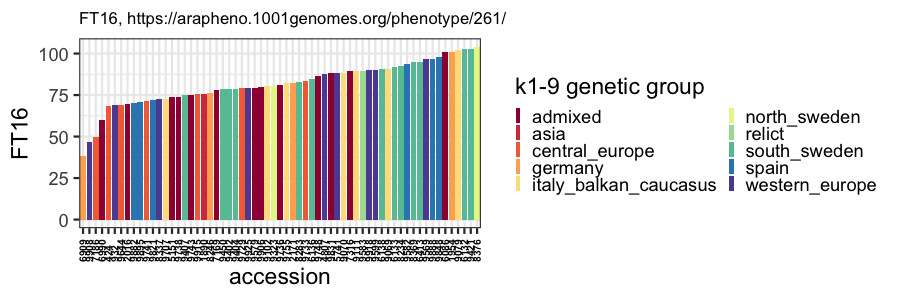

In [4]:
%%R -w 6 -h 2 --units in -r 150
df <- read_delim("./FT16_parents.csv", ",", escape_double = FALSE)
mycolors <- brewer.pal(10, "Spectral")
ggplot(df, aes(x=reorder(ID_wt_1, FT16_1001), y=FT16_1001)) +
geom_bar(stat="identity", aes(fill=`k1-9_group_wt`)) +
theme_bw() +theme(axis.text.x = element_text(face = "bold", color = "#000000", size = 5, angle = 90, vjust=.5, hjust=0)) +
ggtitle('FT16, https://arapheno.1001genomes.org/phenotype/261/') +
theme(plot.title = element_text(size=8)) +
scale_fill_manual(values = mycolors) +
theme(legend.key.size = unit(1, 'mm')) +
guides(fill=guide_legend(ncol=2, bycol=TRUE)) +
xlab("accession") + ylab("FT16") + labs(fill = "k1-9 genetic group")
#ggsave("flowering_founder_lines.pdf")

## Fig 5B

In [5]:
%%R -w 7 -h 2 --units in -r 150
world <- map_data("world")

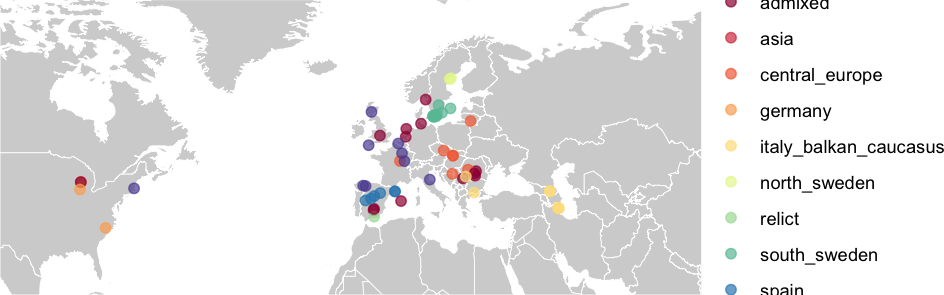

In [6]:
%%R -w 16 -h 5 --units cm -r 150
df <- read_delim("./FT16_parents.csv", ",", escape_double = FALSE)
mycolors <- brewer.pal(10, "Spectral")
ggplot() +
geom_map(data = world, map = world, aes(long, lat, map_id = region),color = "white", fill = "lightgray", size = 0.2) +
geom_point(data = df, aes(long_wt, lat_wt, color=`k1-9_group_wt`), size=2, alpha = 0.7) +
theme_void() +
ylim(25,75) + xlim(-100,80) +
scale_colour_manual(values = mycolors)
#ggsave('geo_dist_lines.pdf', dpi=300, width=16, height=5, units='cm', useDingbats=FALSE)

### inlet of Fig 5B

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Parsed with column specification:
cols(
  `k1-9_group_wt` = col_character(),
  count = col_double()
)

  warnings.warn(x, RRuntimeWarning)


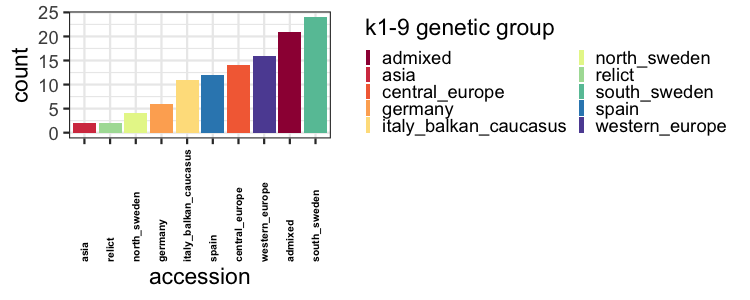

In [7]:
%%R -w 5 -h 2 --units in -r 150
df <- read_delim("./lines_group.csv", ",", escape_double = FALSE)
mycolors <- brewer.pal(10, "Spectral")
ggplot(df, aes(x=reorder(`k1-9_group_wt`, count), y=count)) +
geom_bar(stat="identity", aes(fill=`k1-9_group_wt`)) +
theme_bw() +theme(axis.text.x = element_text(face = "bold", color = "#000000", size = 5, angle = 90, vjust=.5, hjust=0)) +
theme(plot.title = element_text(size=8)) +
scale_fill_manual(values = mycolors) +
theme(legend.key.size = unit(1, 'mm')) +
guides(fill=guide_legend(ncol=2, bycol=TRUE)) +
xlab("accession") + ylab("count") + labs(fill = "k1-9 genetic group")
#ggsave('lines_per_gen_group.pdf')

## Fig. 5E

In [8]:
%%R -w 11 -h 4 --units in -r 150
df <- read.delim("./coverage_per_base_selected.csv", ",", header=T, row.names="position")
df2 <- df[2:113]
df_annot <- read.delim('lines_info_annot.csv', ",", header=T)
annot <- df_annot[c('ID_wt_2', 'del_screen', 'FLC_qRT_mut')]
row.names(annot) <- colnames(df2)
annot_row <- df[c(115)]

df2[df2 > 2] <- 1

pheatmap(df2, filename='coverage_analysis_FLC_1.png', height=4, width=10, fontsize_row = 1, fontsize_col = 6, border_color = "NA", annotation_col=annot, annotation_row=annot_row, cluster_cols = FALSE, cluster_rows = FALSE,color = colorRampPalette(rev(brewer.pal(n = 2, name = "YlOrRd")))(2))

## Fig. 5F - left

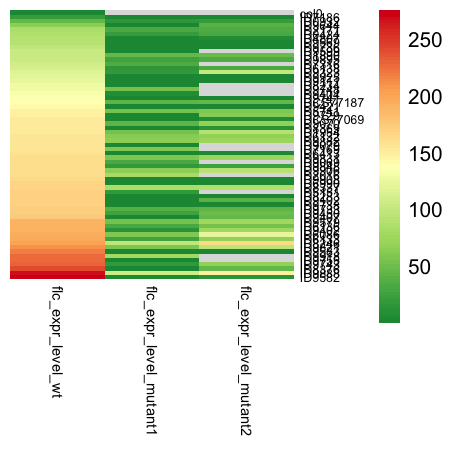

In [9]:
%%R -w 3 -h 3 --units in -r 150
df <- read.delim("./ct_2_grouped_reduced_pivot_rearrange.csv", ",", header=T, row.names="accession")
df2 <- df[1:3]
pheatmap(df2,fontsize_row = 6, fontsize_col = 7, border_color = "NA", cluster_rows = FALSE, cluster_cols = FALSE, color = colorRampPalette(rev(brewer.pal(n = 5, name = "RdYlGn")))(100))


## Fig. 5F - right

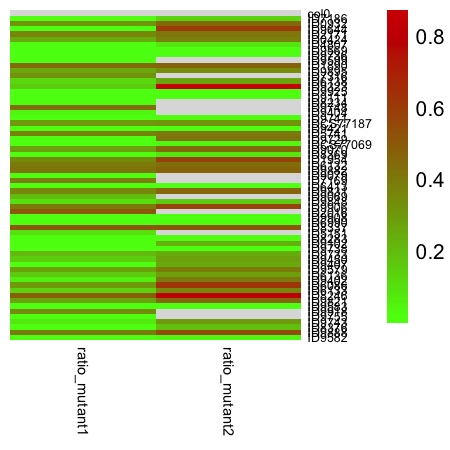

In [10]:
%%R -w 3 -h 3 --units in -r 150
df <- read.delim("./ct_2_grouped_reduced_pivot_rearrange.csv", ",", header=T, row.names="accession")
df2 <- df[4:5]
pal <- colorRampPalette(c("#55ff0f", '#d40000'))
pheatmap(df2, fontsize_row = 6, fontsize_col = 7, color=pal(300), border_color = "NA", cluster_rows = FALSE, cluster_cols = FALSE, )

## Fig. 6A

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Parsed with column specification:
cols(
  .default = col_double(),
  line = col_character(),
  label = col_character(),
  hsd_test_early_flow = col_character()
)

  warnings.warn(x, RRuntimeWarning)


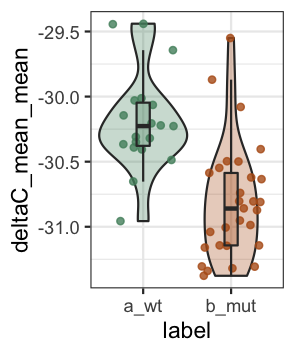

In [11]:
%%R -w 5 -h 6 --units cm -r 150
df <- read_delim("./deltaC_extended_group_rep3.csv", ",", escape_double = FALSE)
df <- subset(df, df$label != 'col')

df$label[df$label == "wt"] <- "a_wt"
df$label[df$label == "mut"] <- "b_mut"

ggplot(df, aes(x=label, y=deltaC_mean_mean)) + 
  geom_violin(aes(fill=label), trim=TRUE, width=1, alpha=.3) + geom_jitter(aes(color=label),size=1.3, alpha=.8, width = 0.35) +  geom_boxplot(aes(fill=label), alpha=.3, width=0.15, outlier.shape = NA)+
    theme_bw() + theme(legend.position = "none") + scale_fill_manual(values=c("#538f6d", "#b65d1d")) + scale_color_manual(values=c("#538f6d", "#b65d1d"))

#ggsave('deltaC_mut_wt_viol_2.pdf', dpi=300, width=5, height=6.5, units='cm', useDingbats=FALSE)

## Fig. 6B

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: Parsed with column specification:
cols(
  .default = col_double(),
  line = col_character(),
  label = col_character(),
  hsd_test_early_flow = col_character(),
  wt_name = col_character()
)

  warnings.warn(x, RRuntimeWarning)


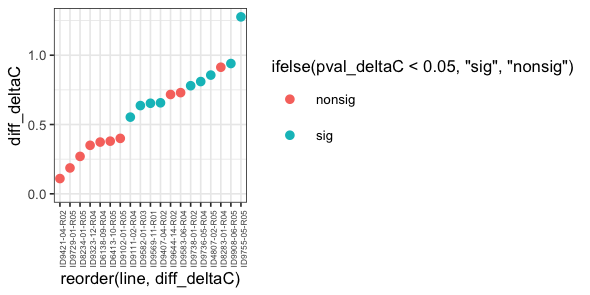

In [12]:
%%R -w 10 -h 5 --units cm -r 150
df <- read_delim("./deltaC_extended_group_rep3_pval.csv", ",", escape_double = FALSE)

df <- df[!(is.na(df$pval_deltaC)), ]

ggplot(df, aes(x=reorder(line,diff_deltaC), y=diff_deltaC, color=ifelse(pval_deltaC<0.05, "sig", "nonsig"))) +
geom_point() + theme_bw(base_size=8) + 
theme(axis.text.x = element_text(angle = 90, size=4)) + ylim(0,NA)

#ggsave('deltaC_ratio_mut_wt_2_diff.pdf', dpi=300, width=10, height=5, units='cm', useDingbats=FALSE)

## Fig 6C

/anaconda3/lib/python3.6/site-packages/rpy2/rinterface/__init__.py:145: RRuntimeWarning: `geom_smooth()` using formula 'y ~ x'

  warnings.warn(x, RRuntimeWarning)


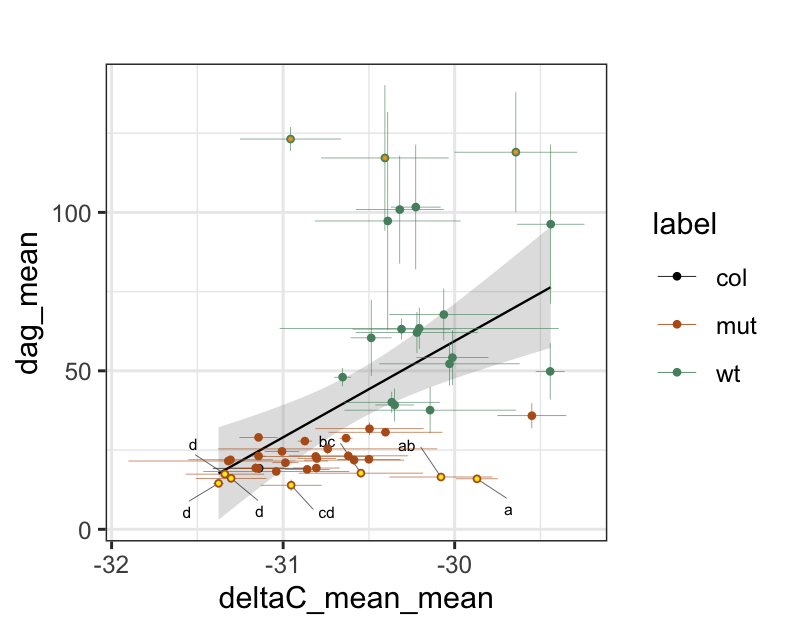

In [13]:
%%R -w 10 -h 8 --units cm -r 200
df <- read_delim("./deltaC_extended_group_rep3.csv", ",", escape_double = FALSE)

ggplot(df, aes(x=deltaC_mean_mean, y=dag_mean)) + 
    ggtitle("") + 
    theme_bw() +
    geom_smooth(method="lm", se=TRUE, size=.4, alpha=.3, color="black") +
    scale_colour_manual(values=c("#000000", "#b65d1d", "#538f6d")) +
    geom_text_repel(aes(label=hsd_test_early_flow),segment.size = 0.1, box.padding = 0.6, max.overlaps = Inf, size=2) +
    geom_errorbar(aes(color=label, ymin=dag_mean-dag_std, ymax=dag_mean+dag_std), width=0, position=position_dodge(0.05), size = .1) +
    geom_errorbar(aes(color=label,xmin=deltaC_mean_mean-deltaC_mean_std, xmax=deltaC_mean_mean+deltaC_mean_std), width=0, position=position_dodge(0.05),size = .1) +
    geom_point(aes(color=label),alpha=1, size=.8) +
    geom_point(data = df[df$dag_mean <= 18,], aes(x=deltaC_mean_mean, y=dag_mean),color="yellow", alpha=0.8, size=.2) +
    geom_point(data = df[df$dag_mean >= 110,], aes(x=deltaC_mean_mean, y=dag_mean),color="orange", alpha=0.8, size=.2)

#ggsave('scatter_deltaC_dag_marg_hist_2.pdf', dpi=300, width=8, height=6, units='cm', useDingbats=FALSE)